In [1]:
#This script aims to develop a csv file of two columns headered as "t" and "mmHg" which model the inflation and deflation of a BP cuff
#Author: Joshua Van Tuyl
#VitalCentric Project

#Imports
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

#Importing healthy blood pressure data
b = pd.read_csv("Healthy_BP_JVT_12_2025.csv")
#Saving csv columns as data lists
healthy_data = b.to_dict(orient="list")
#Saving each column as a discrete list
time = healthy_data["0"]
healthy_bp = healthy_data["80"]
#Healthy BP data called h(t)

In [2]:
#Create Gaussian Function g(t)
#Takes in inputs of time and outputs values
#A is a scaling constant
def gauss(t, mu, sigma, A):
    g = A * np.exp(-1 * ((t - mu)**2) / (2 * sigma**2))
    return g

In [3]:
#Exponential decay
y0 = 180
k = 0.085

def decay(t, y0, k):
    c = y0 * np.exp(-k*t)
    return c

In [4]:
#saving linear decay data, need deflation pressure > 0 

t_decay = np.linspace(0, 22, 1208)
p = decay(t_decay, y0, k)


In [5]:
#Extracting when local maxima (systolic pressure) occurs
test = find_peaks(healthy_bp)
peaks_index = test[0].tolist()
#peaks_index is a list of indices that correspond to pressure values in healthy_bp
systole = []
t_maxima = []
for x in range(0, len(peaks_index)):
    systole.append(healthy_bp[peaks_index[x]])
    t_maxima.append(time[peaks_index[x]])

In [6]:
#extracting when local minima occurs
invert = []
for x in range(0, len(healthy_bp)):
    invert.append(-1 * healthy_bp[x])
mins = find_peaks(invert)
vall_index = mins[0].tolist()
#vall_index is a list of indices that ciorrespond to local pressure minima in healthy_bp
diastole = []
t_minima = []
for x in range(0, len(vall_index)):
    diastole.append(healthy_bp[vall_index[x]])
    t_minima.append(time[vall_index[x]])

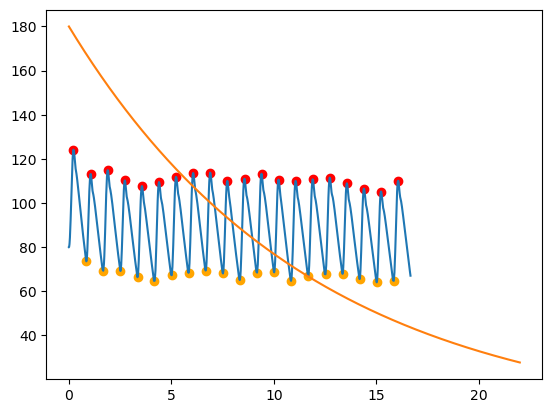

In [7]:
plt.scatter(t_maxima, systole, color="red")
plt.scatter(t_minima, diastole, color="orange")
plt.plot(time, healthy_bp)
plt.plot(t_decay, p)

In [8]:

timestamps = []
index = []

for x in range(0, len(systole)):

    t = 0
    
    test = systole[x]

    for i in range(0, len(healthy_bp)):

        if test == healthy_bp[i]:
            
            timestamps.append(time[i])
            index.append(i)



In [9]:
index

[45,
 97,
 165,
 251,
 336,
 371,
 416,
 474,
 533,
 576,
 614,
 665,
 728,
 765,
 808,
 863,
 923,
 985,
 1056,
 1125]

In [14]:
m = []

for x in range(0, len(time)):
    g = 180 * np.exp(-0.085 * time[x])
    m.append(g)

for x in range(0, len(index)):

    #Systolic spikes
    if x > 5 and x < 13:
        m[index[x]] = m[index[x]] + 2
        m[index[x] + 1] = m[index[x] + 1] + 1
        m[index[x] - 1] = m[index[x] - 1] + 1
    if x == 8:
        m[index[x]] = m[index[x]] + 1
    if x == 9:
        m[index[x]] = m[index[x]] + 1
    if x == 10:
        m[index[x]] = m[index[x]] + 1.5
    if x == 11:
        m[index[x]] = m[index[x]] + 1.7

In [ ]:
plt.plot(time, m)
plt.plot(time, healthy_bp)